# Random Forest para Detección de PCOS

En este notebook implementaremos un modelo de **Random Forest** para la detección de Síndrome de Ovario Poliquístico (PCOS) utilizando el dataset procesado.

El Random Forest es un método de aprendizaje por conjunto (ensemble) que opera construyendo una multitud de árboles de decisión durante el entrenamiento y generando la clase que es la moda de las clases (clasificación) o la predicción media (regresión) de los árboles individuales.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay, roc_curve
from sklearn.tree import plot_tree
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')

## Carga de Datos

In [ ]:
df = pd.read_csv('../../data/processed/PCOS_data_cleaned.csv')

df.head()

,y,Age,Weight,Height,BMI,BloodGroup,PulseRate,RR,Hb,Cycle,...,Pimples,FastFood,RegExercise,BPSystolic,BPDiastolic,FollicleNoL,FollicleNoR,AvgFsizeL,AvgFsizeR,Endometrium
0,0,28,44.6,152.0,19.3,15,78,22,10.48,2,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,0,36,65.0,161.5,24.9,15,74,20,11.70,2,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,1,33,68.8,165.0,25.3,11,72,18,11.80,2,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,0,37,65.0,148.0,29.7,13,72,20,12.00,2,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,0,25,52.0,161.0,20.1,11,72,18,10.00,2,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 42 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   y               541 non-null    int64  
 1   Age             541 non-null    int64  
 2   Weight          541 non-null    float64
 3   Height          541 non-null    float64
 4   BMI             541 non-null    float64
 5   BloodGroup      541 non-null    int64  
 6   PulseRate       541 non-null    int64  
 7   RR              541 non-null    int64  
 8   Hb              541 non-null    float64
 9   Cycle           541 non-null    int64  
 10  CycleLength     541 non-null    int64  
 11  MarraigeStatus  540 non-null    float64
 12  Pregnant        541 non-null    int64  
 13  NoAbortions     541 non-null    int64  
 14  IbetaHCG        541 non-null    float64
 15  IIbetaHCG       541 non-null    float64
 16  FSH             541 non-null    float64
 17  LH              541 non-null    flo

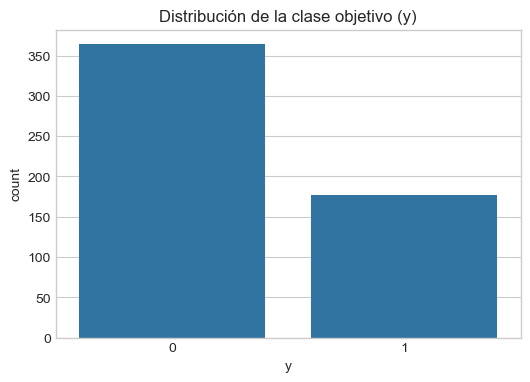

y
0    0.672828
1    0.327172
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df)
plt.title('Distribución de la clase objetivo (y)')
plt.show()

print(df['y'].value_counts(normalize=True))

## Preprocesamiento y División de Datos

In [ ]:
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test: {X_test.shape}")

Tamaño de X_train: (378, 41)
Tamaño de X_test: (163, 41)


## Implementación del Modelo Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluación del Modelo

In [ ]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8957


In [19]:
# Reporte de clasificación detallado
print("=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred))

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

           0       0.89      0.96      0.93       110
           1       0.91      0.75      0.82        53

    accuracy                           0.90       163
   macro avg       0.90      0.86      0.88       163
weighted avg       0.90      0.90      0.89       163



<Figure size 800x600 with 0 Axes>

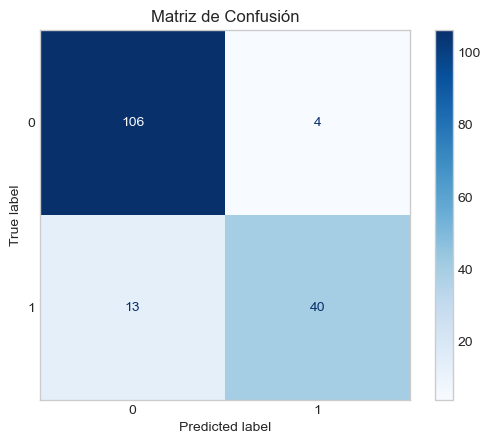

In [20]:
# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión')
plt.grid(False)
plt.show()

ROC AUC Score: 0.9408


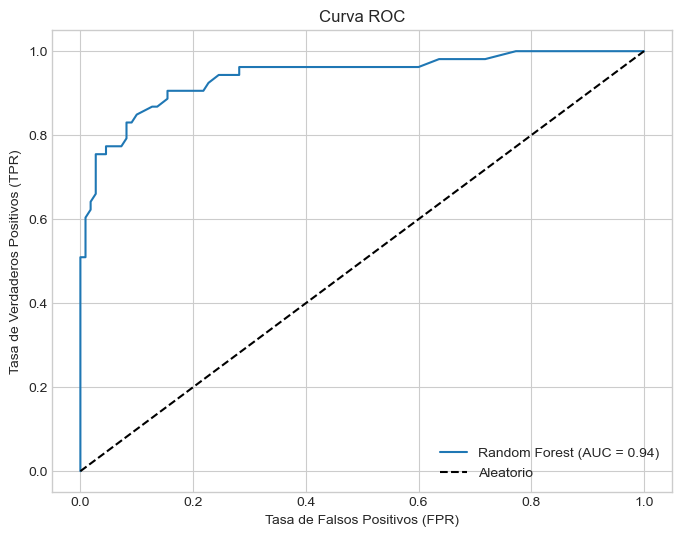

In [21]:
# Curva ROC y AUC
auc_score = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {auc_score:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

## Importancia de Características

Una de las ventajas de los Random Forests es que nos permiten inspeccionar la importancia de cada característica en la predicción.

/var/folders/h8/vtv9bx_x4lv6302qf1vy44180000gn/T/ipykernel_12467/4084152727.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')


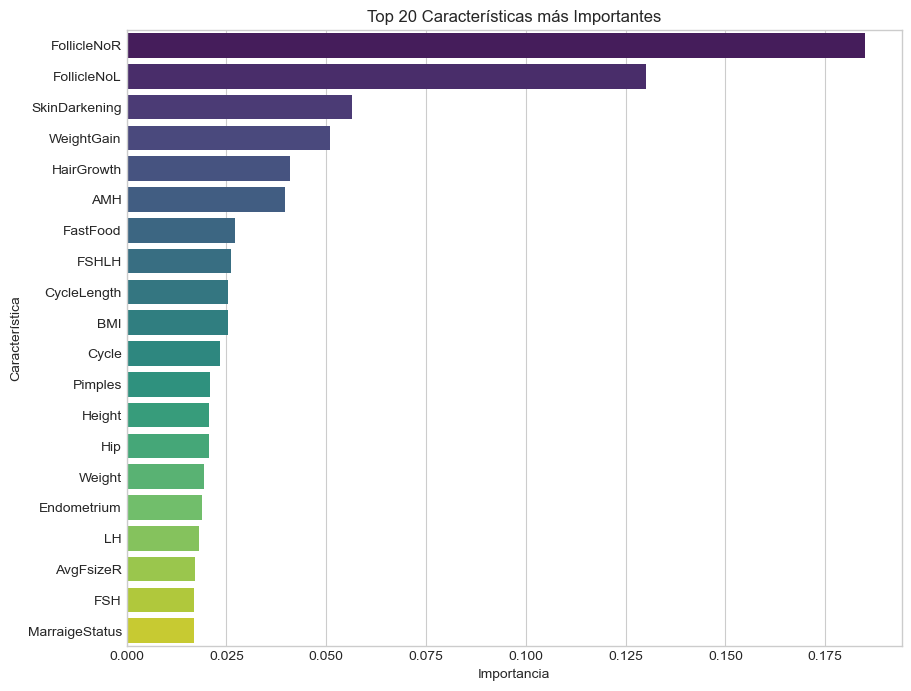

In [ ]:
importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')
plt.title('Top 20 Características más Importantes')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()

## Visualización de Árboles

Visualizaremos uno de los árboles del bosque para entender mejor las reglas de decisión.

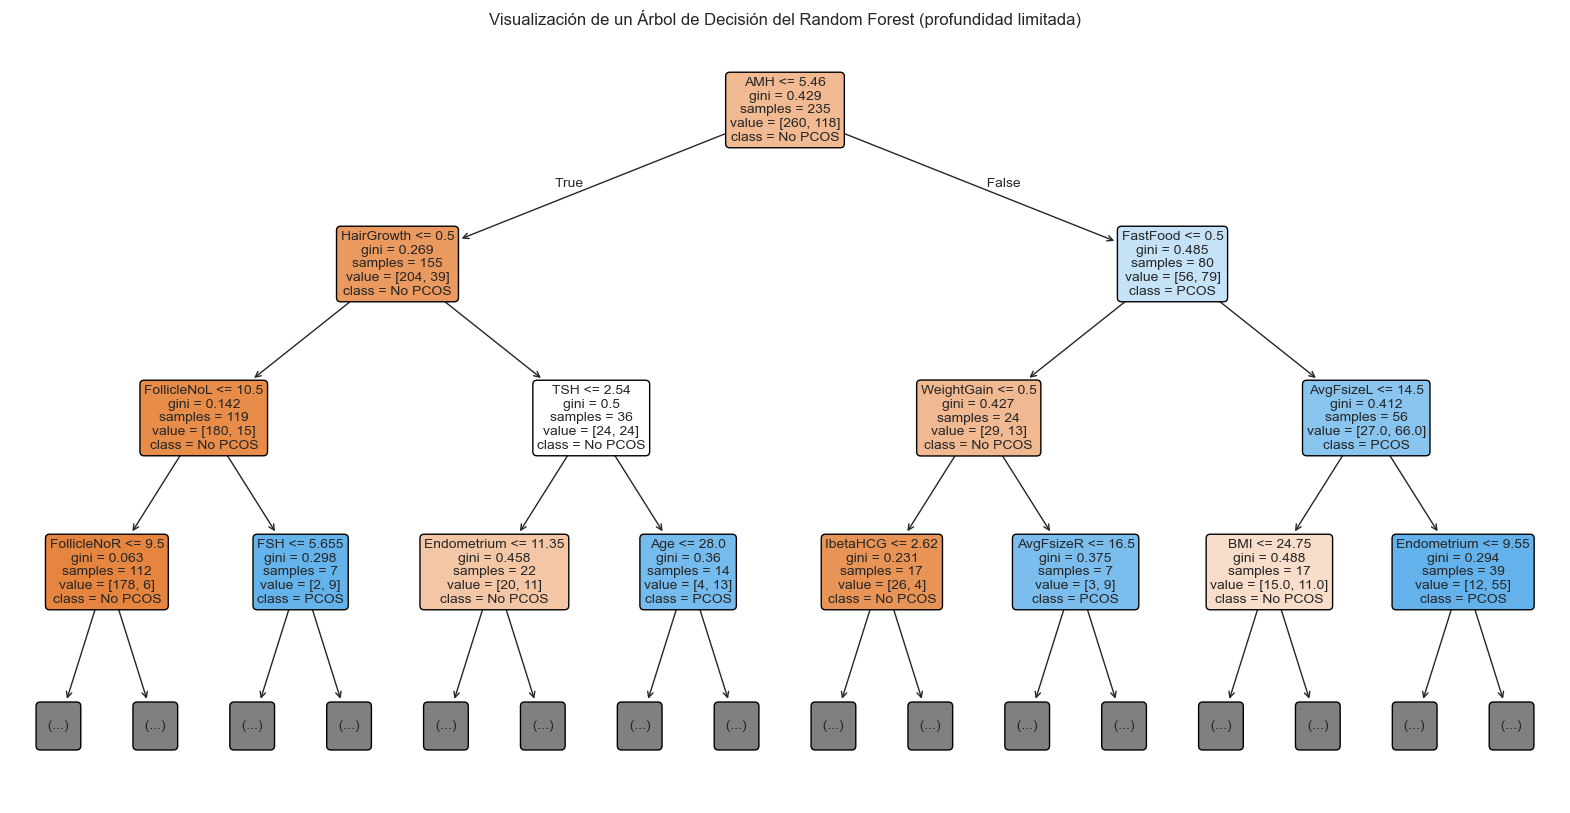

In [ ]:
tree_to_plot = rf_model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(tree_to_plot, 
          filled=True, 
          feature_names=X.columns, 
          class_names=['No PCOS', 'PCOS'], 
          rounded=True, 
          fontsize=10,
          max_depth=3)
plt.title('Visualización de un Árbol de Decisión del Random Forest (profundidad limitada)')
plt.show()